#### 9.7.1.2 Truncating Time Steps


##### Tổng quan về Truncated Backpropagation Through Time
Truncated Backpropagation Through Time (TBPTT) là một phương pháp tối ưu hóa quá trình huấn luyện các mạng nơ-ron hồi tiếp (RNN) trên các chuỗi dữ liệu dài, bằng cách chia chuỗi đầu vào thành các đoạn con (subsequences) có độ dài cố định.

##### Nguyên lý hoạt động
- Forward pass:
    - Mỗi đoạn con được xử lý tuần tự. Trạng thái ẩn (hidden state) từ đoạn con trước được truyền sang làm giá trị khởi tạo cho đoạn con tiếp theo.
    - Ví dụ: Nếu chuỗi gốc dài 100 bước thời gian được chia thành 4 đoạn (mỗi đoạn 25 bước), hidden state ở bước 25 sẽ dùng làm đầu vào cho đoạn 26–50.
- Backward pass:
    - Gradient chỉ được tính toán trong phạm vi từng đoạn con và bị "cắt bỏ" (truncated) khi chuyển sang đoạn tiếp theo.
    - Khác với BPTT tiêu chuẩn (gradient lan truyền qua toàn bộ chuỗi), TBPTT ngăn gradient từ đoạn sau ảnh hưởng đến đoạn trước nếu vượt quá độ dài đoạn con.

##### Ưu điểm của phương pháp trên:
1. Giảm nguy cơ gradient vanishing/exploding:
    - Việc giới hạn số bước $\tau$ làm giảm số lượng tích các ma trận Jacobian $\prod_{j=i+1}^t \frac{\partial f}{\partial h_{j-1}}$, từ đó:
        - Tránh tích luỹ các giá trị Jacobian nhỏ (< 1) gây gradient vanishing 

2. Tiết kiệm bộ nhớ
    - Chỉ lưu trữ gradient cho $\tau$ bước gần nhất, giảm đáng kể yêu cầu bộ nhớ
3. Tốc độ
    - Giảm chi phí tính toán cho chuỗi dài khi số phép tính giảm từ O($T$) xuống còn O($\tau$)

##### Hạn chế:
- Việc giới hạn số bước khiến cho các phụ thuộc từ đầu chuỗi không được xét đến, dẫn đến giảm hiệu suất trong các tác vụ yêu cầu bộ nhớ dài
- Gradient tính toán không chính xác như Full Computation, nhưng vẫn đủ tốt để huấn luyện hiệu quả

##### Ứng dụng thực tế:
- Mô hình ngôn ngữ (Language Models): xử lý văn bản dài
- Dự báo chuỗi thời gian: Dự báo giá cổ phiếu, thời tiết
- Xử lý âm thanh: Nhận dạng giọng nói

##### Hiện thực:

In [2]:
import torch
from torch import nn
from torch.nn import functional as F
from d2l import torch as d2l
import numpy as np
import matplotlib.pyplot as plt

Đầu tiên, ta xây dựng mô hình RNN đơn giản từ đầu qua lớp RNNScratch, có nhiệm vụ thực hiện quá trình tính toán cho chuỗi đầu vào qua các bước thời gian.

In [3]:
class RNNScratch(d2l.Module):  
    def __init__(self, num_inputs, num_hiddens, sigma=0.01):
        """
        Args:
            num_inputs (int): Kích thước input features
            num_hiddens (int): Kích thước hidden state
            sigma (float): Độ lệch chuẩn cho khởi tạo trọng số
        """
        super().__init__()
        self.save_hyperparameters()
        self.W_xh = nn.Parameter(
            torch.randn(num_inputs, num_hiddens) * sigma)
        self.W_hh = nn.Parameter(
            torch.randn(num_hiddens, num_hiddens) * sigma)
        self.b_h = nn.Parameter(torch.zeros(num_hiddens))

    def forward(self, inputs, state=None):
        """
        Args:
            inputs (Tensor): Input sequence tensor 
                shape: (num_steps, batch_size, num_inputs)
            state (tuple, optional): Hidden state tuple. Defaults to None.
        
        Returns:
            outputs (list): Danh sách các hidden states qua tất cả time steps
            state (tuple): Final hidden state
        """
        if state is None:
            # Khởi tạo hidden state đầu tiên
            state = (torch.zeros((inputs.shape[1], self.num_hiddens),
                            device=inputs.device),)
        else:
            state = state
        outputs = []
        h, = state
        for X in inputs: # Duyệt qua từng time step
            h = torch.tanh(torch.matmul(X, self.W_xh) +
                            torch.matmul(h, self.W_hh) + self.b_h)
            outputs.append(h)
        return outputs, (h,) 

Tiếp theo, ta định nghĩa lớp RNNLMScratch để xây dựng mô hình ngôn ngữ (Language Model) sử dụng RNN để dự đoán các từ trong chuỗi văn bản

In [4]:
class RNNLMScratch(d2l.Classifier):  #@save
    def __init__(self, rnn, vocab_size, lr=0.01, tau=32):
        """
        Args:
            rnn (RNNScratch): Instance của RNN
            vocab_size (int): Kích thước từ điển
            lr (float): Learning rate
            tau (int): Kích thước chunk cho Truncated BPTT
        """
        super().__init__()
        self.save_hyperparameters()
        self.init_params()

    def init_params(self):
        """Khởi tạo parameters cho output layer"""
        self.W_hq = nn.Parameter(
            torch.randn(
                self.rnn.num_hiddens, self.vocab_size) * self.rnn.sigma)
        self.b_q = nn.Parameter(torch.zeros(self.vocab_size))

    def training_step(self, batch):
        """Xử lý một batch training và tính loss
        Args:
            batch (tuple): Chứa inputs và targets 
                (X, Y) với shape (batch_size, num_steps)
        """
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=True)
        return l

    def validation_step(self, batch):
        """Xử lý một batch validation và tính loss"""
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('ppl', torch.exp(l), train=False)

    def one_hot(self, X):
        """Chuyển đổi indices sang one-hot vectors
        Args:
            X (Tensor): Input tensor indices shape (num_steps, batch_size)
        Returns:
            Tensor: One-hot tensor shape (num_steps, batch_size, vocab_size)
        """
        return F.one_hot(X.T, self.vocab_size).type(torch.float32)

    def output_layer(self, rnn_outputs):
        """Biến đổi hidden states sang logits
        Args:
            rnn_outputs (list): Danh sách các hidden states từ RNN
        Returns:
            Tensor: Logits shape (batch_size, num_steps, vocab_size)
        """
        outputs = [torch.matmul(H, self.W_hq) + self.b_q for H in rnn_outputs]
        return torch.stack(outputs, 1)

    def forward(self, X, state=None):
        """
        Forward pass với Truncated BPTT
        Args:
            X (Tensor): Input tensor indices shape (batch_size, num_steps)
            state (tuple, optional): Initial hidden state. Defaults to None.
        
        Returns:
            Tensor: Logits predictions shape (batch_size, num_steps, vocab_size)
        """
        embs = self.one_hot(X)
        tau = self.tau
        all_outputs = []
        hidden = state
        num_steps = embs.shape[0]

        # Xử lý input theo từng chunk kích thước tau
        for i in range(0, num_steps, tau):
            chunk = embs[i:i+tau]
            if hidden is not None:
                # Ngắt gradient giữa các chunk cho Truncated BPTT
                hidden = tuple(h.detach() for h in hidden)
            # Forward qua RNN cho chunk hiện tại
            rnn_outputs, hidden = self.rnn(chunk, hidden)
            all_outputs.extend(rnn_outputs)

        # Áp dụng output layer cho tất cả outputs
        return self.output_layer(all_outputs)

    def predict(self, prefix, num_preds, vocab, device=None):
        """
        Dự đoán chuỗi ký tự
        Args:
            prefix (str): Chuỗi khởi đầu
            num_preds (int): Số ký tự cần dự đoán
            vocab (Vocab): Đối tượng từ điển
            device (torch.device, optional): Thiết bị tính toán
            
        Returns:
            str: Chuỗi kết quả đã được dự đoán
        """
        state, outputs = None, [vocab[prefix[0]]]
        for i in range(len(prefix) + num_preds - 1):
            X = torch.tensor([[outputs[-1]]], device=device)
            embs = self.one_hot(X)
            rnn_outputs, state = self.rnn(embs, state)
            if i < len(prefix) - 1:  
                outputs.append(vocab[prefix[i + 1]])
            else:  
                Y = self.output_layer(rnn_outputs)
                outputs.append(int(Y.argmax(axis=2).reshape(1)))
        return ''.join([vocab.idx_to_token[i] for i in outputs])

Sau khi định nghĩa các lớp, ta tiến hành quá trình huấn luyện một mô hình RNN để dự đoán chuỗi văn bản như sau:
- Batch size được chọn là 128 để tối ưu hiệu suất tính toán trên GPU đồng thời đảm bảo ước lượng gradient ổn định, phù hợp với kích thước dataset Time Machine.
- Độ dài chuỗi (num_inputs) được chọn là 32 để mô hình nắm bắt các mid-term dependency trong văn bản. Giá trị này phù hợp với tham số tau=5 nhằm đánh giá tác động của TBPTT lên gradient flow.
- kích thước trạng thái ẩn (num_hiddens) được chọn là 128 dựa trên thực nghiệm, đảm bảo mô hình đủ sức biểu diễn các pattern phức tạp trong khi tránh overfitting.
- Learning Rate (lr) được chọn là 0.1 để tăng tốc hội tụ, kết hợp với gradient clipping (ngưỡng 1) nhằm ổn định quá trình lan truyền ngược.
- Chunk size (tau) được chọn là 5 để hạn chế gradient vanishing/exploding, đồng thời đánh giá sự đánh đổi giữa hiệu suất tính toán và khả năng học phụ thuộc dài hạn của TBPTT.
- Mô hình được huấn luyện trong 100 epoch để đảm bảo hội tụ tối ưu mà không rơi vào trạng thái overfitting.
- Gradient clipping được áp dụng với ngưỡng 1 để ổn định quá trình cập nhật trọng số, đặc biệt khi kết hợp với learning rate cao.

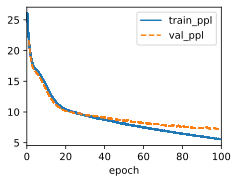

In [7]:
data = d2l.TimeMachine(batch_size=128, num_steps=32)
rnn = RNNScratch(num_inputs=len(data.vocab), num_hiddens=128)
model = RNNLMScratch(rnn, vocab_size=len(data.vocab), lr=0.1, tau=5)
trainer = d2l.Trainer(max_epochs=100, gradient_clip_val=1, num_gpus=1)
trainer.fit(model, data)

Đồ thị thể hiện sự thay đổi của Perplexity trong quá trình huấn luyện:
- Đường màu xanh (train_ppl) thể hiện mức độ phức tạp của mô hình khi huấn luyện.
- Đường màu đỏ (val_ppl) thể hiện mức độ phức tạp của mô hình trên dữ liệu kiểm tra. 

1. Giai đoạn đầu (Epoch 0 - 20):
- Cả train_ppl và val_ppl giảm mạnh từ 25 xuống 10, cho thấy mô hình học nhanh các pattern cơ bản trong dữ liệu
- Khoảng cách giữa 2 đường rất nhỏ $\rightarrow$ chưa có dấu hiệu overfitting
2. Giai đoạn giữa (Epoch 20 - 60):
- Tốc độ giảm chậm lại: train_ppl giảm từ 10 xuống 5 trong khi val_ppl giảm từ 10 xuống 7.
- Khoảng cách giữa train và val tăng nhẹ $\rightarrow$ Mô hình bắt đầu học chi tiết hơn trên tập huấn luyện, nhưng vẫn duy trì khả năng khái quát hóa.
3. Giai đoạn cuối (Epoch 60-100):
- train_ppl tiếp tục giảm chậm, đạt xấp xỉ 3-4 ở epoch 100
- val_ppl ổn định quanh 7-8, không có dấu hiệu tăng đột ngột $\rightarrow$ không xảy ra overfitting nghiêm trọng

Khi thực hiện dự đoán với câu khởi đầu "it has" và yêu cầu sinh thêm 20 ký tự, mô hình trả về kết quả:

In [9]:
model.predict('it has', 20, data.vocab, d2l.try_gpu())

'it has a for and the time '

Có thể thấy tuy chuỗi được sinh ra chưa được mạch lạc do các vấn đề như kiến trúc còn đơn giản, sự hạn chế của khả năng học dependency ở xa, cấu trúc văn bản chưa đủ đa dạng để mô hình học ngữ cảnh phức tạp. Nhưng nhìn chung, ta vẫn thấy được một số điều tích cực như chuỗi dự đoán phù hợp với chủ đề của dataset và mô hình đã học được một số pattern đơn giản (ví dụ như cấu trúc "it has a ...").